Material properties: mu=384.615, kappa=833.333
Step 0, load factor = 1.000
Iteration 1, Correction=1.000000e+00, Residual=8.067898e-06, tolerance=1.000000e-10
Iteration 2, Correction=7.459018e-03, Residual=2.888737e-04, tolerance=1.000000e-10
Iteration 3, Correction=4.067475e-04, Residual=4.933270e-08, tolerance=1.000000e-10
Iteration 4, Correction=1.788270e-08, Residual=6.889236e-11, tolerance=1.000000e-10
Iteration 5, Correction=2.159314e-15, Residual=5.698519e-16, tolerance=1.000000e-10
Analytical solution: -0.136500
Numerical solution: -0.140217
Absolute error: 3.716940e-03
Relative error: 2.7230%


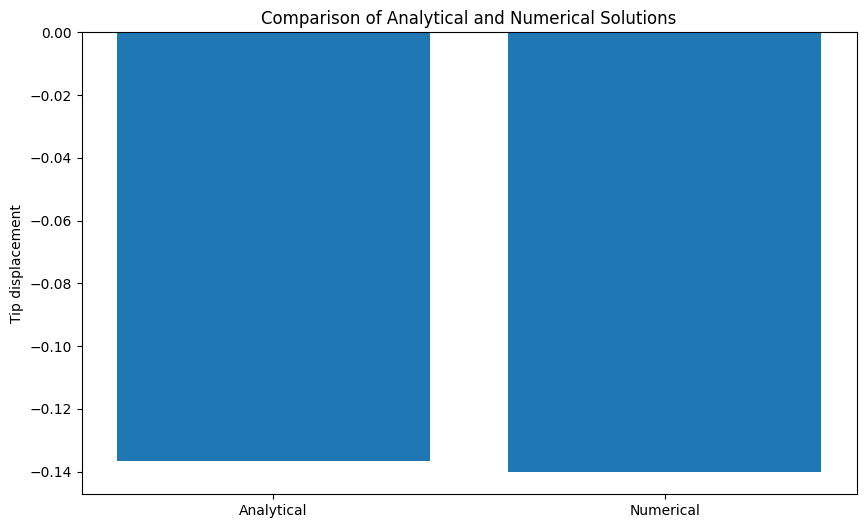

In [ ]:
from finiteelementanalysis import pre_process as pre
from finiteelementanalysis.solver import hyperelastic_solver
import matplotlib.pyplot as plt
import numpy as np

# Beam geometry
L = 10.0   # length in x
H = 1.0    # height in y

# Material properties
E = 1000.0
nu = 0.3
mu = E / (2.0 * (1.0 + nu))
kappa = E / (3.0 * (1.0 - 2.0 * nu))
material_props = np.array([mu, kappa])

print(f"Material properties: mu={mu:.3f}, kappa={kappa:.3f}")

# Load (small load for validation)
q = -0.01  # load per unit length in x

# Mesh parameters
nx = 40    # number of elements along length
ny = 4     # number of elements along height
ele_type = "D2_nn6_tri"  # 2D, 6-node triangular elements

# Solver settings
nr_num_steps = 1
nr_tol = 1e-10
nr_maxit = 30

def run_analysis():
    coords, connect = pre.generate_rect_mesh_2d(ele_type, 0.0, 0.0, L, H, nx, ny)
    
    boundary_nodes, boundary_edges = pre.identify_rect_boundaries(
        coords, connect, ele_type, x_lower=0.0, x_upper=L, y_lower=0.0, y_upper=H
    )
    
    fixed_left = pre.assign_fixed_nodes_rect(boundary_nodes, "left", 0.0, 0.0)
    dload_info = pre.assign_uniform_load_rect(boundary_edges, "top", 0.0, q)
    fixed_nodes = fixed_left
    
    displacements_all, nr_info_all = hyperelastic_solver(
        material_props, ele_type, coords.T, connect.T, fixed_nodes, dload_info,
        nr_print=True, nr_num_steps=nr_num_steps, nr_tol=nr_tol, nr_maxit=nr_maxit,
    )
    
    final_disp = displacements_all[-1]
    
    tip_node = None
    tol = 1e-3
    for i, (x, y) in enumerate(coords):
        if abs(x - L) < tol and abs(y - H/2) < H/(2*ny):
            tip_node = i
            break
    if tip_node is None:
        raise ValueError("Could not find tip node near x=L, y=H/2.")
    
    tip_disp_y = final_disp[2*tip_node + 1]
    
    return tip_disp_y

# Analytical solution
E_eff = E / (1 - nu ** 2.0)
I = H ** 3 / 12.0
w_analytical = q * L ** 4 / (8.0 * E_eff * I)

# Numerical solution
w_numerical = run_analysis()

# Calculate error
error = abs(w_numerical - w_analytical)
relative_error = error / abs(w_analytical) * 100

print(f"Analytical solution: {w_analytical:.6f}")
print(f"Numerical solution: {w_numerical:.6f}")
print(f"Absolute error: {error:.6e}")
print(f"Relative error: {relative_error:.4f}%")

# Plot results
plt.figure(figsize=(10, 6))
plt.bar(['Analytical', 'Numerical'], [w_analytical, w_numerical])
plt.ylabel("Tip displacement")
plt.title("Comparison of Analytical and Numerical Solutions")
#plt.savefig("validation_comparison.png")
plt.show()
plt.close()